In [1]:

import calendar
import os
import pandas as pd
import xarray as xr
import numpy as np
import cdsapi
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
EXCEL_FILE = "Projectfile_test_Kaushik.xlsx"
START_DATE = "1995-01-01"
END_DATE   = "2026-03-31"
DAILY_DIR  = Path("/Volumes/T5 EVO/era5land_daily")   # per-year NetCDFs
OUT_DIR    = Path("/Volumes/T5 EVO/era5land_raw")
FINAL_NC   = OUT_DIR / "ERA5_Land_1995-01-01_2026-03-31_daily_Nigeria.nc"

DAILY_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# 3-hourly timesteps (8 per day)
TIMES_3H = ["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00"]

# ── One CDS variable per download request ────────────────────────────────────
# (cds_variable, short_name, agg_methods, is_accumulated, times)
#
# Accumulated vars  → download only "00:00" UTC (holds full 24-h total)
#                     value is used directly; no deaccumulation needed.
# Instantaneous vars → download all 3-hourly steps; resample to daily stats.
VAR_GROUPS = [
    ("2m_temperature",                   "t2m",   ["mean", "min", "max"], False, TIMES_3H),
    ("2m_dewpoint_temperature",           "d2m",   ["mean"],               False, TIMES_3H),
    ("surface_solar_radiation_downwards", "ssrd",  ["sum"],                True,  ["00:00"]),
    ("10m_u_component_of_wind",           "u10",   ["mean"],               False, TIMES_3H),
    ("10m_v_component_of_wind",           "v10",   ["mean"],               False, TIMES_3H),
    ("volumetric_soil_water_layer_1",     "swvl1", ["mean"],               False, TIMES_3H),
    ("soil_temperature_level_1",          "stl1",  ["mean"],               False, TIMES_3H),
    ("total_precipitation",              "tp",    ["sum"],                True,  ["00:00"]),
    ("potential_evaporation",            "pev",   ["sum"],                True,  ["00:00"]),
]

# ============================================================
# READ POINTS  (x = lon, y = lat)
# ============================================================
df_proj = pd.read_excel(EXCEL_FILE)
points = (
    df_proj[["x", "y"]]
    .drop_duplicates()
    .rename(columns={"x": "lon", "y": "lat"})
    .reset_index(drop=True)
)
print(f"Unique points: {len(points)}")
print(points.head())

# ── Bounding box [N, W, S, E] ─────────────────────────────────────────────────
buf  = 0.5
area = [
    round(points["lat"].max() + buf, 2),
    round(points["lon"].min() - buf, 2),
    round(points["lat"].min() - buf, 2),
    round(points["lon"].max() + buf, 2),
]
print(f"Bounding box [N, W, S, E]: {area}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def magnus_rh(t_k, td_k):
    t  = t_k  - 273.15
    td = td_k - 273.15
    return 100.0 * np.exp((17.625 * td) / (243.04 + td)) / \
                   np.exp((17.625 * t ) / (243.04 + t ))


date_range  = pd.date_range(START_DATE, END_DATE, freq="YS")   # one entry per year


all_years   = [d.year for d in date_range]
print(f"Years to process: {all_years[0]} – {all_years[-1]}")

Unique points: 7340
    lon   lat
0  6.15  4.35
1  6.35  4.35
2  6.45  4.35
3  6.55  4.35
4  5.85  4.45
Bounding box [N, W, S, E]: [14.35, 2.25, 3.85, 15.15]
Years to process: 1995 – 2026


In [ ]:

# ── CELL 2: FETCH — download raw 3-hourly / 00:00-UTC files from CDS ─────────

c = cdsapi.Client()

for year in all_years:
    yr_nc = DAILY_DIR / f"ERA5Land_daily_{year}.nc"
    if yr_nc.exists():
        print(f"{year}: annual file already exists, skipping fetch.")
        continue

    for month in range(1, 13):
        end_of_month = pd.Timestamp(year=year, month=month,
                                    day=calendar.monthrange(year, month)[1])
        if pd.Timestamp(START_DATE) > end_of_month:
            continue
        if pd.Timestamp(END_DATE) < pd.Timestamp(f"{year}-{month:02d}-01"):
            break

        n_days = calendar.monthrange(year, month)[1]
        days   = [f"{d:02d}" for d in range(1, n_days + 1)]

        for cds_var, short_name, agg_methods, is_accum, times in VAR_GROUPS:
            var_nc = DAILY_DIR / f"era5land_{short_name}_{year}_{month:02d}.nc"

            if var_nc.exists():
                print(f"  {year}-{month:02d} [{short_name}]: cached.")
                continue

            print(f"  {year}-{month:02d} [{short_name}]: downloading …",
                  end=" ", flush=True)
            c.retrieve(
                "reanalysis-era5-land",
                {
                    "variable":        [cds_var],
                    "year":            str(year),
                    "month":           f"{month:02d}",
                    "day":             days,
                    "time":            times,
                    "area":            area,
                    "download_format": "unarchived",
                    "format":          "netcdf",
                },
                str(var_nc),
            )
            print("done")

print("\nFetch complete.")


  1995-01 [t2m]: cached.
  1995-01 [d2m]: cached.
  1995-01 [ssrd]: cached.
  1995-01 [u10]: cached.
  1995-01 [v10]: cached.
  1995-01 [swvl1]: cached.
  1995-01 [stl1]: cached.
  1995-01 [tp]: cached.
  1995-01 [pev]: cached.
  1995-02 [t2m]: cached.
  1995-02 [d2m]: cached.
  1995-02 [ssrd]: cached.
  1995-02 [u10]: cached.
  1995-02 [v10]: downloading … 

2026-05-26 19:53:52,037 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-26 19:53:52,038 INFO Request ID is 1e2d7d31-6bc2-4277-b50e-654686b177ed
2026-05-26 19:53:52,259 INFO status has been updated to accepted
Recovering from HTTP error [500 Internal Server Error], attempt 1 of 500
Retrying in 120 seconds
2026-05-26 19:58:28,508 INFO status has been updated to successful


141fe809c7f8474960de614f953e235a.nc:   0%|          | 0.00/5.32M [00:00<?, ?B/s]

done
  1995-02 [swvl1]: downloading … 

2026-05-26 19:58:33,412 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-26 19:58:33,412 INFO Request ID is 07218253-cb0c-46fc-a5cb-b36334f041d5
2026-05-26 19:58:33,499 INFO status has been updated to accepted
2026-05-26 19:58:47,535 INFO status has been updated to running
2026-05-26 19:59:49,985 INFO status has been updated to successful


...

done
  2007-12 [u10]: downloading … 

2026-05-28 09:04:55,986 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-28 09:04:55,987 INFO Request ID is e9314bd2-97a6-41dd-81f6-8d632d3cb5cc
2026-05-28 09:04:56,080 INFO status has been updated to accepted
2026-05-28 09:05:09,727 INFO status has been updated to running
2026-05-28 09:06:12,810 INFO status has been updated to successful


f96c42dbd8364d6dfebb67470ca2c64b.nc:   0%|          | 0.00/5.87M [00:00<?, ?B/s]

done
  2007-12 [v10]: downloading … 

2026-05-28 09:06:16,573 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-28 09:06:16,574 INFO Request ID is 432b010b-f4ea-41cf-a793-aed826ab3984
2026-05-28 09:06:18,500 INFO status has been updated to accepted


In [ ]:

# ── CELL 3: LOAD — aggregate to daily, derive CF vars, write annual NetCDFs ──

from dask.distributed import Client, LocalCluster

n_workers = min(os.cpu_count(), 8)
cluster   = LocalCluster(n_workers=n_workers, threads_per_worker=2, memory_limit="4GB")
client    = Client(cluster)
print(f"Dask dashboard : {client.dashboard_link}")

year_files = []

for year in all_years:
    yr_nc = DAILY_DIR / f"ERA5Land_daily_{year}.nc"
    year_files.append(yr_nc)

    if yr_nc.exists():
        print(f"{year}: already done, skipping.")
        continue

    month_ds = []

    for month in range(1, 13):
        end_of_month = pd.Timestamp(year=year, month=month,
                                    day=calendar.monthrange(year, month)[1])
        if pd.Timestamp(START_DATE) > end_of_month:
            continue
        if pd.Timestamp(END_DATE) < pd.Timestamp(f"{year}-{month:02d}-01"):
            break

        agg_datasets = []

        for cds_var, short_name, agg_methods, is_accum, times in VAR_GROUPS:
            var_nc = DAILY_DIR / f"era5land_{short_name}_{year}_{month:02d}.nc"

            ds_v = xr.open_dataset(var_nc)
            if "valid_time" in ds_v.dims:
                ds_v = ds_v.rename({"valid_time": "time"})

            sv     = list(ds_v.data_vars)[0]
            da     = ds_v[sv]
            agg_ds = xr.Dataset()

            if is_accum:
                # 00:00 UTC snapshot = full 24-h accumulation → one value per day
                agg_ds[f"{short_name}_sum"] = (
                    da.squeeze("time", drop=True)
                    if da.sizes["time"] == 1
                    else da.isel(time=0)
                )
            else:
                for agg in agg_methods:
                    out_name = f"{short_name}_{agg}"
                    if agg == "mean":
                        agg_ds[out_name] = da.resample(time="1D").mean()
                    elif agg == "min":
                        agg_ds[out_name] = da.resample(time="1D").min()
                    elif agg == "max":
                        agg_ds[out_name] = da.resample(time="1D").max()

            ds_v.close()
            agg_datasets.append(agg_ds)

            # Remove raw file immediately to free disk
            if var_nc.exists():
                var_nc.unlink()

        ds_m = xr.merge(agg_datasets)
        month_ds.append(ds_m)

    if not month_ds:
        continue

    # ── Merge months → derive CF variables → write annual NetCDF ─────────────
    ds_yr = xr.concat(month_ds, dim="time")

    ds_out = xr.Dataset({
        "tas":     ds_yr["t2m_mean"]  - 273.15,
        "tasmin":  ds_yr["t2m_min"]   - 273.15,
        "tasmax":  ds_yr["t2m_max"]   - 273.15,
        "pr":      ds_yr["tp_sum"]    * 1000.0,    # m → mm/day
        "rsds":    ds_yr["ssrd_sum"]  / 86400.0,   # J m⁻²/day → W m⁻²
        "pet":     ds_yr["pev_sum"]   * -1000.0,   # m → mm/day, flip sign
        "swvl1":   ds_yr["swvl1_mean"],
        "stl1":    ds_yr["stl1_mean"] - 273.15,
        "hurs":    magnus_rh(ds_yr["t2m_mean"], ds_yr["d2m_mean"]),
        "sfcWind": np.sqrt(ds_yr["u10_mean"]**2 + ds_yr["v10_mean"]**2),
    })

    attrs = {
        "tas":     ("degC",   "Daily mean 2 m temperature"),
        "tasmin":  ("degC",   "Daily minimum 2 m temperature"),
        "tasmax":  ("degC",   "Daily maximum 2 m temperature"),
        "pr":      ("mm/day", "Total precipitation"),
        "rsds":    ("W/m2",   "Surface downwelling shortwave radiation"),
        "pet":     ("mm/day", "Potential evapotranspiration"),
        "swvl1":   ("m3/m3",  "Volumetric soil water layer 1"),
        "stl1":    ("degC",   "Soil temperature layer 1"),
        "hurs":    ("%",      "Relative humidity"),
        "sfcWind": ("m/s",    "Near-surface wind speed"),
    }
    for var, (unit, lname) in attrs.items():
        ds_out[var].attrs = {"units": unit, "long_name": lname}

    ds_out = ds_out.chunk({"time": 365,
                            "latitude":  ds_out.sizes["latitude"],
                            "longitude": ds_out.sizes["longitude"]})
    ds_out.to_netcdf(yr_nc, compute=True)
    print(f"{year}: saved → {yr_nc}")

client.close()
cluster.close()
print("\nAll years processed.")

# ── Extract points + merge all years into one final NetCDF ───────────────────
print(f"Merging {len(year_files)} annual files and extracting points …")
ds_all = xr.open_mfdataset([f for f in year_files if f.exists()], combine="by_coords")
ds_all = ds_all.sel(time=slice(START_DATE, END_DATE))

lats_da = xr.DataArray(points["lat"].values, dims="points")
lons_da = xr.DataArray(points["lon"].values, dims="points")
ds_pts  = ds_all.sel(latitude=lats_da, longitude=lons_da, method="nearest")
ds_pts  = ds_pts.assign_coords(
    input_lat=("points", points["lat"].values),
    input_lon=("points", points["lon"].values),
)

ds_pts.to_netcdf(FINAL_NC)
ds_all.close()
print(f"Final file saved → {FINAL_NC}")


In [ ]:

import json
import os
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# CF → SIMPLACE column name mapping
CF_TO_SIMPLACE = {
    "tas":      "TempMean",
    "tasmin":   "TempMin",
    "tasmax":   "TempMax",
    "pr":       "Precipitation",
    "rsds":     "Radiation",
    "pet":      "ETpot",
    "hurs":     "RelHum",
    "sfcWind":  "Windspeed",
    "swvl1":    "SoilWaterL1",
    "stl1":     "SoilTempL1",
}

# Unit conversions: Radiation W/m² → kJ/m²/day;  Wind 10 m → 2 m (log profile)
_W2 = np.log(2.0 / 0.01) / np.log(10.0 / 0.01)   # ≈ 0.7482
UNIT_CONVERSIONS = {
    "Radiation": lambda x: x * 86.4,
    "Windspeed":  lambda x: x * _W2,
}

UNITS = {
    "TempMean":      "°C",
    "TempMin":       "°C",
    "TempMax":       "°C",
    "Precipitation": "mm",
    "Radiation":     "kJ m-2",
    "ETpot":         "mm day-1",
    "RelHum":        "%",
    "Windspeed":     "m s-1",
    "SoilWaterL1":   "m³/m³",
    "SoilTempL1":    "°C",
}


# ── Worker function (runs in thread pool) ────────────────────────────────────
def _write_point(base_dir, lat_dim, lon_dim, lat, lon, row, col,
                 simplace_vars, df_all, time_col):
    """Slice one point from the pre-loaded DataFrame and write its CSV."""
    rel_file = f"{col}/ERA5Land_Daily_C{col}R{row}.csv"
    out_path = base_dir / rel_file

    # Select rows for this exact grid point
    mask  = (df_all[lat_dim] == lat) & (df_all[lon_dim] == lon)
    df_pt = df_all.loc[mask, [time_col] + simplace_vars].copy()
    df_pt.rename(columns={time_col: "Date"}, inplace=True)
    df_pt["Date"] = pd.to_datetime(df_pt["Date"]).dt.date

    (base_dir / str(col)).mkdir(parents=True, exist_ok=True)
    df_pt.to_csv(out_path, index=False, sep="\t")

    return rel_file, float(lat), float(lon), row, col


def nc_to_simplace(nc_path: str, out_dir: str = "simplace_output",
                   max_workers: int = None) -> str:
    """Read a daily ERA5-Land NetCDF and write SIMPLACE-format CSVs in parallel.

    Strategy:
        1. Load the entire dataset into memory once  (single disk read)
        2. Apply unit conversions in-place
        3. Convert to a flat DataFrame
        4. Distribute per-point CSV writes across a ThreadPoolExecutor

    Args:
        nc_path:     Path to the NetCDF file.
        out_dir:     Root output directory.
        max_workers: Thread count (default: min(32, cpu_count + 4)).

    Returns:
        Absolute path to out_dir.
    """
    nc_path  = Path(nc_path)
    base_dir = Path(out_dir)
    base_dir.mkdir(parents=True, exist_ok=True)

    if max_workers is None:
        max_workers = min(32, (os.cpu_count() or 4) + 4)

    # ── 1. Open + load into memory (ONE disk read) ────────────────────────────
    print("Loading NetCDF into memory …")
    ds = xr.open_dataset(nc_path, chunks={"time": 365})

    lat_dim = next(d for d in ds.dims if d.lower() in ("latitude", "lat", "y"))
    lon_dim = next(d for d in ds.dims if d.lower() in ("longitude", "lon", "x"))
    lats = sorted(ds[lat_dim].values.tolist(), reverse=True)  # N→S
    lons = sorted(ds[lon_dim].values.tolist())                # W→E
    lat_to_row = {v: i for i, v in enumerate(lats)}
    lon_to_col = {v: j for j, v in enumerate(lons)}

    # Rename CF → SIMPLACE
    rename_map   = {v: CF_TO_SIMPLACE[v] for v in ds.data_vars if v in CF_TO_SIMPLACE}
    ds_renamed   = ds.rename(rename_map)
    simplace_vars = list(rename_map.values())

    # Apply unit conversions before loading
    for var, fn in UNIT_CONVERSIONS.items():
        if var in ds_renamed:
            ds_renamed[var] = fn(ds_renamed[var])

    # Single .load() — parallelised internally by dask if a client exists
    ds_loaded = ds_renamed[simplace_vars].load()
    print(f"Loaded. Grid: {len(lats)} lats × {len(lons)} lons = {len(lats)*len(lons)} points")

    # ── 2. Flatten to DataFrame once ─────────────────────────────────────────
    df_all = ds_loaded.to_dataframe().reset_index()
    time_col = next(c for c in df_all.columns if c.lower() in ("time", "date"))
    ds_loaded.close()
    ds.close()

    n_total = len(lats) * len(lons)
    print(f"Writing {n_total} CSV files with {max_workers} threads …")

    # ── 3. Parallel CSV writes ────────────────────────────────────────────────
    futures = {}
    mapping_entries = []
    completed = 0

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        for lat in lats:
            for lon in lons:
                row = lat_to_row[lat]
                col = lon_to_col[lon]
                fut = pool.submit(
                    _write_point,
                    base_dir, lat_dim, lon_dim, lat, lon,
                    row, col, simplace_vars, df_all, time_col,
                )
                futures[fut] = (lat, lon, row, col)

        for fut in as_completed(futures):
            rel_file, lat, lon, row, col = fut.result()
            mapping_entries.append({"lat": round(lat, 6), "lon": round(lon, 6),
                                     "row": row, "col": col, "file": rel_file})
            completed += 1
            if completed % 100 == 0:
                print(f"  {completed}/{n_total} written …")

    # ── 4. Write mapping JSON ─────────────────────────────────────────────────
    mapping_entries.sort(key=lambda e: (e["row"], e["col"]))
    mapping = {
        "source_nc": str(nc_path.resolve()),
        "units":     {v: UNITS.get(v, "") for v in simplace_vars},
        "grid": {
            "n_rows":  len(lats),
            "n_cols":  len(lons),
            "lat_min": round(min(lats), 6),
            "lat_max": round(max(lats), 6),
            "lon_min": round(min(lons), 6),
            "lon_max": round(max(lons), 6),
        },
        "mapping": mapping_entries,
    }
    json_path = base_dir / "latlon_to_colrow.json"
    with open(json_path, "w") as fh:
        json.dump(mapping, fh, indent=2)

    print(f"\nDone — {completed} files written to {base_dir.resolve()}")
    print(f"Mapping saved → {json_path}")
    return str(base_dir.resolve())


# ── Run ───────────────────────────────────────────────────────────────────────
nc_to_simplace(
    nc_path="era5land_raw/ERA5_Land_1995-01-01_2025-12-31_daily_Nigeria.nc",
    out_dir="simplace_output",
)


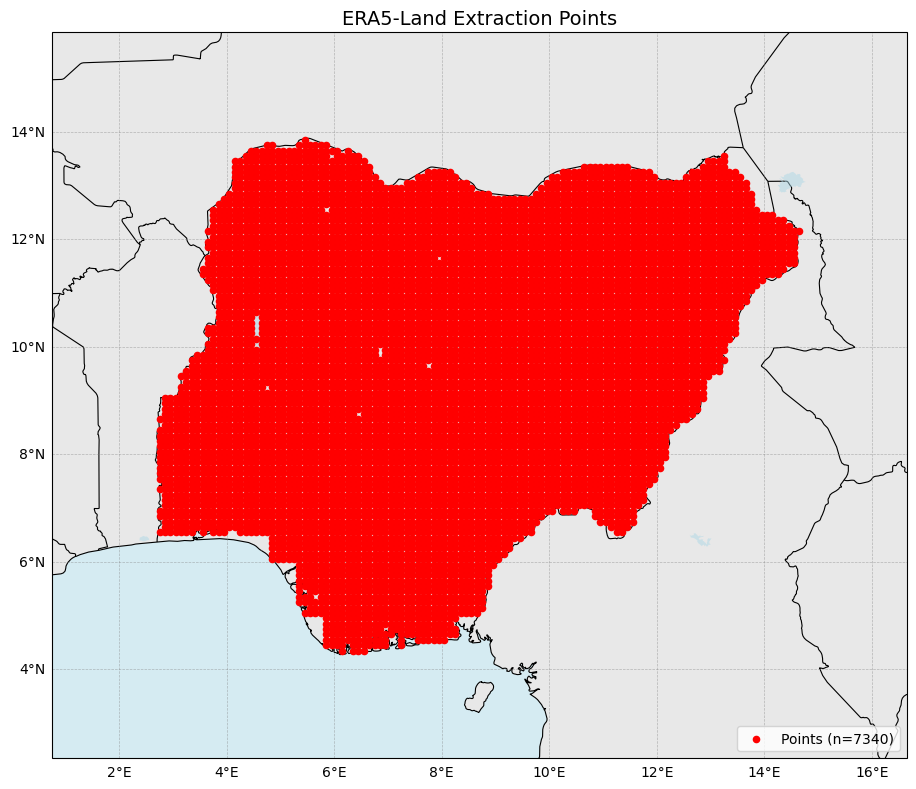

Map saved to extraction_points_map.png


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Add country borders and natural features
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.5)
ax.add_feature(cfeature.LAKES, facecolor="lightblue", alpha=0.5)

# Plot the unique extraction points
ax.scatter(
    points["lon"],
    points["lat"],
    transform=ccrs.PlateCarree(),
    color="red",
    s=20,
    zorder=5,
    label=f"Points (n={len(points)})",
)

# Auto-set extent with a small buffer
lon_min, lon_max = points["lon"].min(), points["lon"].max()
lat_min, lat_max = points["lat"].min(), points["lat"].max()
buf = 2.0
ax.set_extent(
    [lon_min - buf, lon_max + buf, lat_min - buf, lat_max + buf],
    crs=ccrs.PlateCarree(),
)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("ERA5-Land Extraction Points", fontsize=14)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("extraction_points_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved to extraction_points_map.png")
